# TFCE cluster figure — cross-sectional group level (Fig 6 + Table 2)

Group-level patient-vs-control TFCE comparisons of category selectivity within VOTC.

**Cohort:** 38 controls (both hemispheres) · 25 OTC patients, intact hemisphere only (13 LH-intact / 12 RH-intact). One session per subject: controls first, patients last.

**Source:** `group_results/tfce_votc_harmonized/` — the ComBat-harmonized run. Harmonized is primary, not a sensitivity check.

**Contrast coding:** `tstat1` = ctrl > pt (territory loss) · `tstat2` = pt > ctrl (territory gain). FWE p < .05 via `rand_tfce_corrp_tstat{N} > 0.95`, 10k permutations.

**This notebook is trimmed to Fig 6 and Table 2 only.** The category-preference (formerly WTA) composition analyses, Crawford single-case tests, and LMM stats that previously lived here are superseded by `figures_harmonized.ipynb` and `stats_results_harmonized_corrected.csv`.

Surviving clusters are **discovered from the files** rather than hardcoded, so the figure legend and the table can never disagree with what actually survived.


## 1. Setup

In [2]:
# ─── Setup: imports + paths ──────────────────────────────────────────────
import sys
from pathlib import Path
import numpy as np
import nibabel as nib
import pandas as pd
import matplotlib.pyplot as plt
from nilearn import plotting

sys.path.insert(0, '/user_data/csimmon2/git_repos/sym_pt')
from sym_pt_params import processed_dir

# Reference runs (historical):
#   tfce_votc             — cat-vs-others, no threshold, TFCE-FWE
#   tfce_votc_catbaseline — cat-vs-baseline + Ayzenberg threshold, TFCE-FWE
#   tfce_votc_fdr         — cat-vs-others + thresh 0, TFCE-FWE
#   tfce_votc_cluster     — cat-vs-others + thresh 0, cluster-extent FWE @ t>3.09
#   tfce_votc_harmonized  — ComBat-harmonized  <-- PRIMARY (n=25)
TFCE_DIR = Path(processed_dir) / 'group_results' / 'tfce_votc_harmonized'
FIG_DIR  = Path('/user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact')
FIG_DIR.mkdir(parents=True, exist_ok=True)

CORRP_PATTERN = 'rand_tfce_corrp_tstat{tstat}.nii.gz'
TSTAT_PATTERN = 'rand_tstat{tstat}.nii.gz'
CATEGORIES = ['face', 'house', 'object', 'word']
DIRECTION  = {1: 'ctrl>pt', 2: 'pt>ctrl'}

# Minimum cluster extent to treat as reportable. Set to 0 to report every
# surviving voxel; raise it to exclude sub-visible clusters (state the value
# in the manuscript if it is above 0).
MIN_VOX = 0

print('TFCE_DIR:', TFCE_DIR, '| exists:', TFCE_DIR.exists())
print('FIG_DIR :', FIG_DIR)

TFCE_DIR: /user_data/csimmon2/sym_pt/group_results/tfce_votc_harmonized | exists: True
FIG_DIR : /user_data/csimmon2/git_repos/sym_pt/C_results/figures/liu_exact


## 2. Which clusters survived?
Scans all category × hemisphere × direction combinations. `MIN_VOX` controls whether sub-visible clusters are reported — if it is set above 0, state the value in the manuscript.

In [3]:
# ─── Discover surviving clusters (no hardcoded list) ─────────────────────
rows = []
for cat in CATEGORIES:
    for hemi in ('l', 'r'):
        test_dir = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl'
        if not test_dir.exists():
            continue
        for tstat in (1, 2):
            fc = test_dir / CORRP_PATTERN.format(tstat=tstat)
            ft = test_dir / TSTAT_PATTERN.format(tstat=tstat)
            if not fc.exists():
                continue
            corrp_img = nib.load(fc)
            corrp = corrp_img.get_fdata()
            sig = corrp > 0.95
            n_vox = int(sig.sum())
            if n_vox == 0:
                continue
            if ft.exists():
                tvals = nib.load(ft).get_fdata()
                masked_t = np.where(sig, tvals, -np.inf)
                peak_ijk = np.unravel_index(np.argmax(masked_t), masked_t.shape)
                peak_t = float(tvals[peak_ijk])
                peak_mni = nib.affines.apply_affine(corrp_img.affine, peak_ijk)
                peak_pfwe = float(1 - corrp[peak_ijk])
            else:
                peak_t = np.nan; peak_mni = (np.nan,)*3; peak_pfwe = np.nan
            rows.append(dict(category=cat, hemi=hemi, tstat=tstat,
                             direction=DIRECTION[tstat], n_vox=n_vox,
                             mm3=n_vox * 8, peak_t=peak_t, peak_pfwe=peak_pfwe,
                             x=peak_mni[0], y=peak_mni[1], z=peak_mni[2]))

clusters = pd.DataFrame(rows).sort_values('n_vox', ascending=False).reset_index(drop=True)
print(f'Surviving clusters (FWE p<.05), MIN_VOX={MIN_VOX}:')
print(clusters.round(2).to_string(index=False))

reportable = clusters[clusters['n_vox'] >= MIN_VOX].copy()
below = clusters[clusters['n_vox'] < MIN_VOX]
if len(below):
    print(f'\nBelow MIN_VOX and therefore excluded from figures/tables:')
    print(below[['category', 'hemi', 'direction', 'n_vox']].to_string(index=False))

CLUSTER_LIST = [(r.category, r.hemi, int(r.tstat),
                 f'{r.category}_{r.hemi.upper()}  {r.direction}')
                for r in reportable.itertuples()]
GAINS  = [(c, h, t) for c, h, t, _ in CLUSTER_LIST if t == 2]
LOSSES = [(c, h, t) for c, h, t, _ in CLUSTER_LIST if t == 1]
print('\nGAINS  (pt>ctrl):', GAINS)
print('LOSSES (ctrl>pt):', LOSSES)

Surviving clusters (FWE p<.05), MIN_VOX=0:
category hemi  tstat direction  n_vox  mm3  peak_t  peak_pfwe     x     y     z
  object    l      1   ctrl>pt   1229 9832    4.92       0.00 -54.0 -70.0  -4.0
   house    r      1   ctrl>pt    643 5144    3.52       0.00  32.0 -78.0  22.0
    word    r      2   pt>ctrl    552 4416    6.66       0.00  48.0 -64.0  -8.0
    face    l      1   ctrl>pt     31  248    3.37       0.02 -56.0 -70.0  18.0
    word    l      1   ctrl>pt     10   80    3.52       0.04 -30.0 -90.0  -6.0
    face    r      1   ctrl>pt      2   16    3.34       0.05  30.0   2.0 -48.0

GAINS  (pt>ctrl): [('word', 'r', 2)]
LOSSES (ctrl>pt): [('object', 'l', 1), ('house', 'r', 1), ('face', 'l', 1), ('word', 'l', 1), ('face', 'r', 1)]


In [4]:
# ─── BH-FDR across the 8 category x hemisphere comparisons ───────────────
# TFCE gives voxel-level FWE within each test. The reported family is the
# 8 category x hemisphere comparisons, so peak p_FWE values are then
# BH-corrected across all 8 (not just the ones that survived FWE).
# Tests with no surviving voxel enter the family with p_FWE = 1.0.

FAMILY = [(c, h) for c in CATEGORIES for h in ('l', 'r')]

fam_rows = []
for cat, hemi in FAMILY:
    hit = clusters[(clusters.category == cat) & (clusters.hemi == hemi)]
    if len(hit):
        best = hit.loc[hit['peak_pfwe'].idxmin()]
        fam_rows.append(dict(category=cat, hemi=hemi, direction=best.direction,
                             n_vox=int(best.n_vox), peak_t=best.peak_t,
                             p_fwe=float(best.peak_pfwe)))
    else:
        fam_rows.append(dict(category=cat, hemi=hemi, direction='—',
                             n_vox=0, peak_t=np.nan, p_fwe=1.0))
fam = pd.DataFrame(fam_rows)

# Benjamini-Hochberg, step-up
m = len(fam)
fam = fam.sort_values('p_fwe').reset_index(drop=True)
fam['rank'] = np.arange(1, m + 1)
fam['bh_crit'] = fam['rank'] * 0.05 / m
q, run = np.empty(m), 1.0
for i in range(m - 1, -1, -1):
    run = min(run, fam.loc[i, 'p_fwe'] * m / (i + 1))
    q[i] = run
fam['q_fdr'] = q
fam['survives_fdr'] = fam['q_fdr'] < 0.05

print(f'BH-FDR family: {m} category x hemisphere comparisons, q < .05')
print(fam[['category', 'hemi', 'direction', 'n_vox', 'peak_t',
           'p_fwe', 'rank', 'bh_crit', 'q_fdr', 'survives_fdr']]
      .round(5).to_string(index=False))

REPORTABLE = fam[fam['survives_fdr']][['category', 'hemi', 'direction', 'n_vox']]
print(f'\nReportable ({len(REPORTABLE)}):')
print(REPORTABLE.to_string(index=False))

BH-FDR family: 8 category x hemisphere comparisons, q < .05
category hemi direction  n_vox  peak_t  p_fwe  rank  bh_crit   q_fdr  survives_fdr
  object    l   ctrl>pt   1229 4.91897 0.0001     1  0.00625 0.00080          True
    word    r   pt>ctrl    552 6.65637 0.0031     2  0.01250 0.01240          True
   house    r   ctrl>pt    643 3.52125 0.0049     3  0.01875 0.01307          True
    face    l   ctrl>pt     31 3.36767 0.0242     4  0.02500 0.04840          True
    word    l   ctrl>pt     10 3.52021 0.0351     5  0.03125 0.05616         False
    face    r   ctrl>pt      2 3.34239 0.0478     6  0.03750 0.06373         False
   house    l         —      0     NaN 1.0000     7  0.04375 1.00000         False
  object    r         —      0     NaN 1.0000     8  0.05000 1.00000         False

Reportable (4):
category hemi direction  n_vox
  object    l   ctrl>pt   1229
    word    r   pt>ctrl    552
   house    r   ctrl>pt    643
    face    l   ctrl>pt     31


## 3. Table 2 — cluster extents, peaks, anatomical labels

In [5]:
# ─── Table 2 values + Harvard-Oxford labels at each peak ─────────────────
from nilearn import datasets as nl_datasets
ho = nl_datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-2mm')
ho_img = ho.maps if isinstance(ho.maps, nib.Nifti1Image) else nib.load(ho.maps)
ho_data = ho_img.get_fdata()

# % of OTC uses the per-hemisphere VOTC mask voxel counts
otc_n = {}
for hemi in ('l', 'r'):
    f = TFCE_DIR / f'votc_{hemi}_mask.nii.gz'
    otc_n[hemi] = int((nib.load(f).get_fdata() > 0.5).sum()) if f.exists() else np.nan
print('VOTC mask voxels:', otc_n)

out = []
for r in reportable.itertuples():
    ijk = np.round(nib.affines.apply_affine(np.linalg.inv(ho_img.affine),
                                            (r.x, r.y, r.z))).astype(int)
    try:
        label = ho.labels[int(ho_data[tuple(ijk)])]
    except (IndexError, ValueError):
        label = 'n/a'
    out.append(dict(cluster=f'{r.category}_{r.hemi.upper()}', contrast=r.direction,
                    vox=r.n_vox, mm3=r.mm3,
                    pct_otc=round(100 * r.n_vox / otc_n[r.hemi], 1) if otc_n[r.hemi] else np.nan,
                    peak_mni=f'[{r.x:.0f},{r.y:.0f},{r.z:.0f}]',
                    peak_t=round(r.peak_t, 2), p_fwe=round(r.peak_pfwe, 4),
                    ho_label=label))
table2 = pd.DataFrame(out)
print()
print(table2.to_string(index=False))

VOTC mask voxels: {'l': 11340, 'r': 11540}

 cluster contrast  vox  mm3  pct_otc     peak_mni  peak_t  p_fwe                                    ho_label
object_L  ctrl>pt 1229 9832     10.8 [-54,-70,-4]    4.92 0.0001 Lateral Occipital Cortex, inferior division
 house_R  ctrl>pt  643 5144      5.6  [32,-78,22]    3.52 0.0049 Lateral Occipital Cortex, superior division
  word_R  pt>ctrl  552 4416      4.8  [48,-64,-8]    6.66 0.0031 Lateral Occipital Cortex, inferior division
  face_L  ctrl>pt   31  248      0.3 [-56,-70,18]    3.37 0.0242 Lateral Occipital Cortex, superior division
  word_L  ctrl>pt   10   80      0.1 [-30,-90,-6]    3.52 0.0351 Lateral Occipital Cortex, inferior division
  face_R  ctrl>pt    2   16      0.0   [30,2,-48]    3.34 0.0478 Temporal Fusiform Cortex, anterior division


## 4. QC — significant t-stats on the standard brain

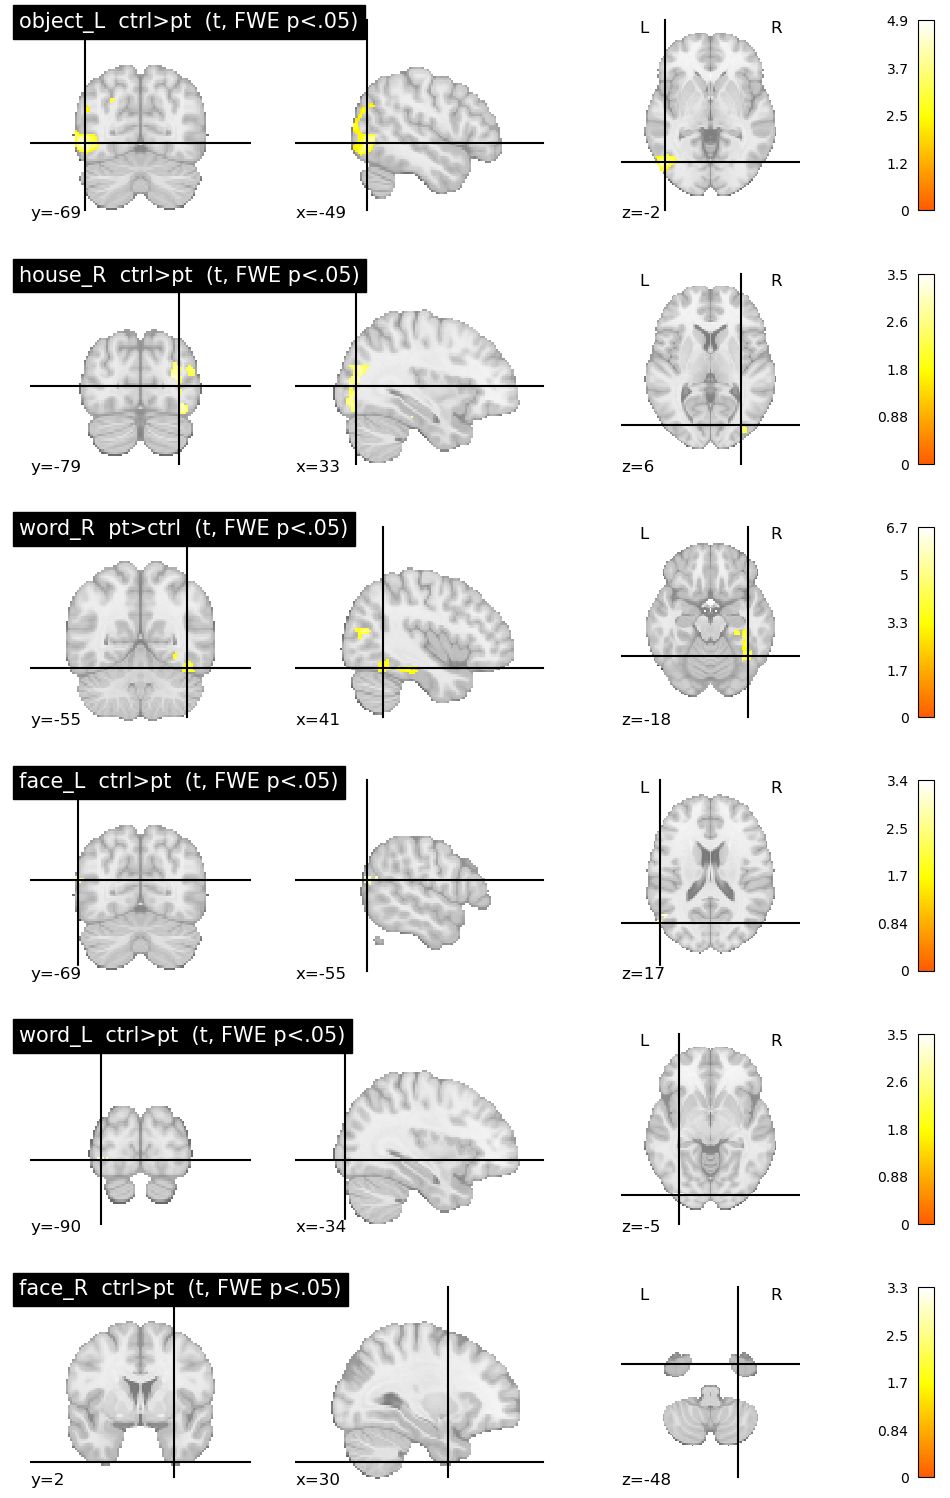

In [6]:
# ─── QC: FWE-significant t-stats on the standard brain (ortho cuts) ──────
# Per-cluster t range is narrow, so vmax is set per panel — colorbars are not
# comparable across rows.
n = len(CLUSTER_LIST)
fig, axes = plt.subplots(n, 1, figsize=(12, 3.2 * n))
axes = np.atleast_1d(axes)
for ax, (cat, hemi, tstat, title) in zip(axes, CLUSTER_LIST):
    test_dir = TFCE_DIR / f'{cat}_{hemi}_pt_vs_ctrl'
    corrp_img = nib.load(test_dir / CORRP_PATTERN.format(tstat=tstat))
    tstat_img = nib.load(test_dir / TSTAT_PATTERN.format(tstat=tstat))
    tstat_data = tstat_img.get_fdata() * (corrp_img.get_fdata() > 0.95)
    masked = nib.Nifti1Image(tstat_data, tstat_img.affine)
    vmax = float(tstat_data.max()) if tstat_data.max() > 0 else 1.0
    plotting.plot_stat_map(masked, threshold=0.01, display_mode='ortho',
                           colorbar=True, cmap='hot', vmax=vmax,
                           title=f'{title}  (t, FWE p<.05)', axes=ax)
plt.show()

## 5. Figure 6 — clusters on inflated surfaces
Two panels: gains (pt > ctrl) and losses (ctrl > pt). Each legend lists only the categories present in that panel.

GAINS_FDR : [('word', 'r', 2)]
LOSSES_FDR: [('object', 'l', 1), ('house', 'r', 1), ('face', 'l', 1)]


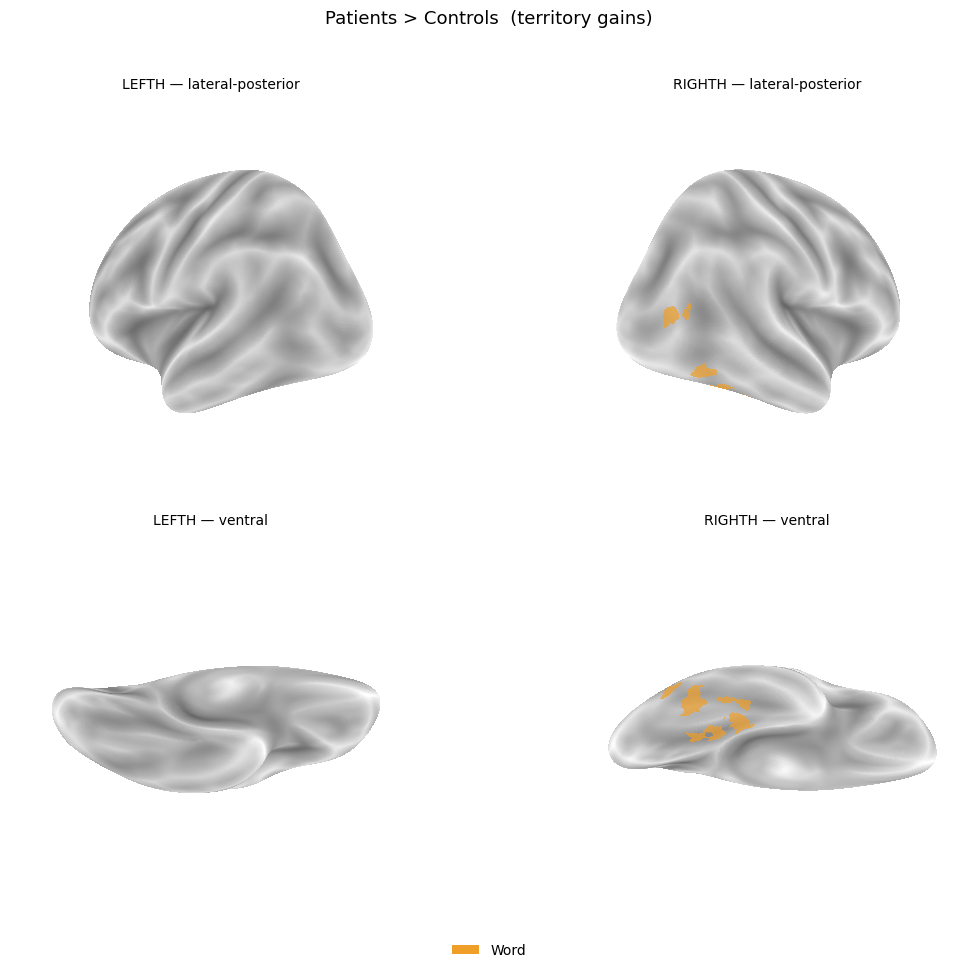

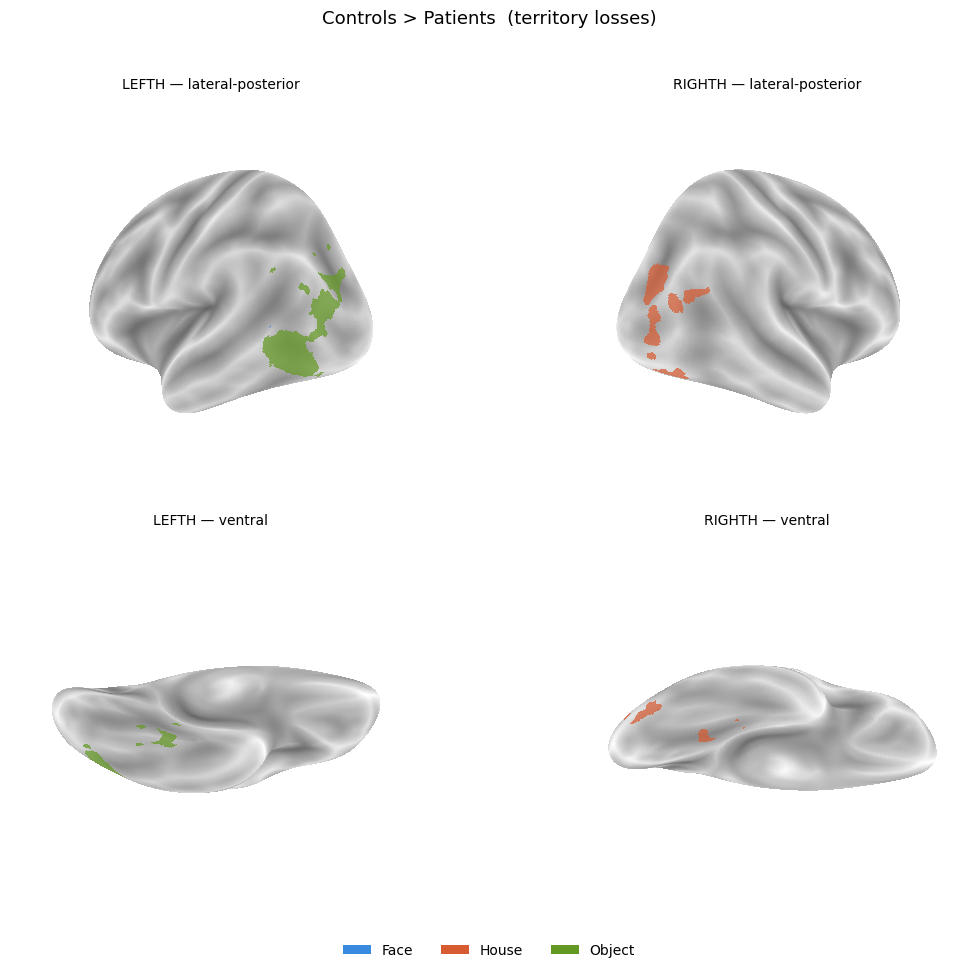

In [7]:
# ─── Fig 6: FDR-surviving TFCE clusters on inflated surfaces ─────────────
# Plots only clusters surviving BH-FDR across the 8 category x hemisphere
# comparisons (see previous cell). Requires REPORTABLE and fam.
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from nilearn import datasets as nl_datasets, surface
from nilearn.plotting import plot_surf_roi

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CAT_INT = {'face': 1, 'house': 2, 'object': 3, 'word': 4}
TSTAT_FOR = {'ctrl>pt': 1, 'pt>ctrl': 2}

# Rebuild gains/losses from the FDR-surviving set only
GAINS_FDR  = [(r.category, r.hemi, TSTAT_FOR[r.direction])
              for r in REPORTABLE.itertuples() if r.direction == 'pt>ctrl']
LOSSES_FDR = [(r.category, r.hemi, TSTAT_FOR[r.direction])
              for r in REPORTABLE.itertuples() if r.direction == 'ctrl>pt']
print('GAINS_FDR :', GAINS_FDR)
print('LOSSES_FDR:', LOSSES_FDR)

VIEWS = {
    'l': [('lateral-posterior', 'lateral', (10, -150)),
          ('ventral',           'ventral', None)],
    'r': [('lateral-posterior', 'lateral', (10,  -30)),
          ('ventral',           'ventral', None)],
}

fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
cat_cmap = ListedColormap(['#cccccc'] + [CAT_COLORS[c] for c in CATEGORIES])


def project_clusters_to_surface(cluster_list, hemi):
    """Combine clusters in one hemisphere into a single surface map (vertex = CAT_INT)."""
    hemi_full = 'left' if hemi == 'l' else 'right'
    n_vert = surface.load_surf_mesh(fsaverage[f'infl_{hemi_full}'])[0].shape[0]
    out = np.zeros(n_vert, dtype=np.int16)
    for cat, h, tstat in cluster_list:
        if h != hemi:
            continue
        fpath = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl' / CORRP_PATTERN.format(tstat=tstat)
        vol_img = nib.load(fpath)
        sig = (vol_img.get_fdata() > 0.95).astype(np.float32)
        sig_img = nib.Nifti1Image(sig, vol_img.affine)
        surf_vals = surface.vol_to_surf(
            sig_img, fsaverage[f'pial_{hemi_full}'],
            radius=3.0, kind='line', interpolation='linear',
        )
        out[surf_vals > 0.3] = CAT_INT[cat]
    return out


for label, cluster_list, tag in [
        ('Patients > Controls  (territory gains)', GAINS_FDR,  'gains'),
        ('Controls > Patients  (territory losses)', LOSSES_FDR, 'losses')]:
    if not cluster_list:
        print(f'no FDR-surviving clusters for: {label}')
        continue
    present = [c for c in CATEGORIES if c in {x[0] for x in cluster_list}]
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': '3d'})
    fig.suptitle(label, fontsize=13, y=0.98)

    for col, (hemi, hemi_full) in enumerate([('l', 'left'), ('r', 'right')]):
        roi_map = project_clusters_to_surface(cluster_list, hemi).astype(float)
        for row, (view_label, view_named, view_custom) in enumerate(VIEWS[hemi]):
            plot_surf_roi(
                fsaverage[f'infl_{hemi_full}'], roi_map=roi_map,
                hemi=hemi_full, view=view_named,
                cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
                bg_map=fsaverage[f'sulc_{hemi_full}'],
                bg_on_data=True, darkness=0.6,
                axes=axes[row, col], figure=fig,
            )
            if view_custom is not None:
                elev, azim = view_custom
                axes[row, col].view_init(elev=elev, azim=azim)
            axes[row, col].set_title(f'{hemi_full.upper()}H — {view_label}', fontsize=10)

    handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in present]
    fig.legend(handles=handles, loc='lower center', ncol=len(present),
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(FIG_DIR / f'tfce_surface_fdr_{tag}.png', dpi=300, bbox_inches='tight')
    plt.show()

GAINS_FDR : [('word', 'r', 2)]
LOSSES_FDR: [('object', 'l', 1), ('house', 'r', 1), ('face', 'l', 1)]

Patients > Controls  (territory gains)


  word_r tstat2: components [409, 72, 58, 12, 1] -> plotted 409/552 vox


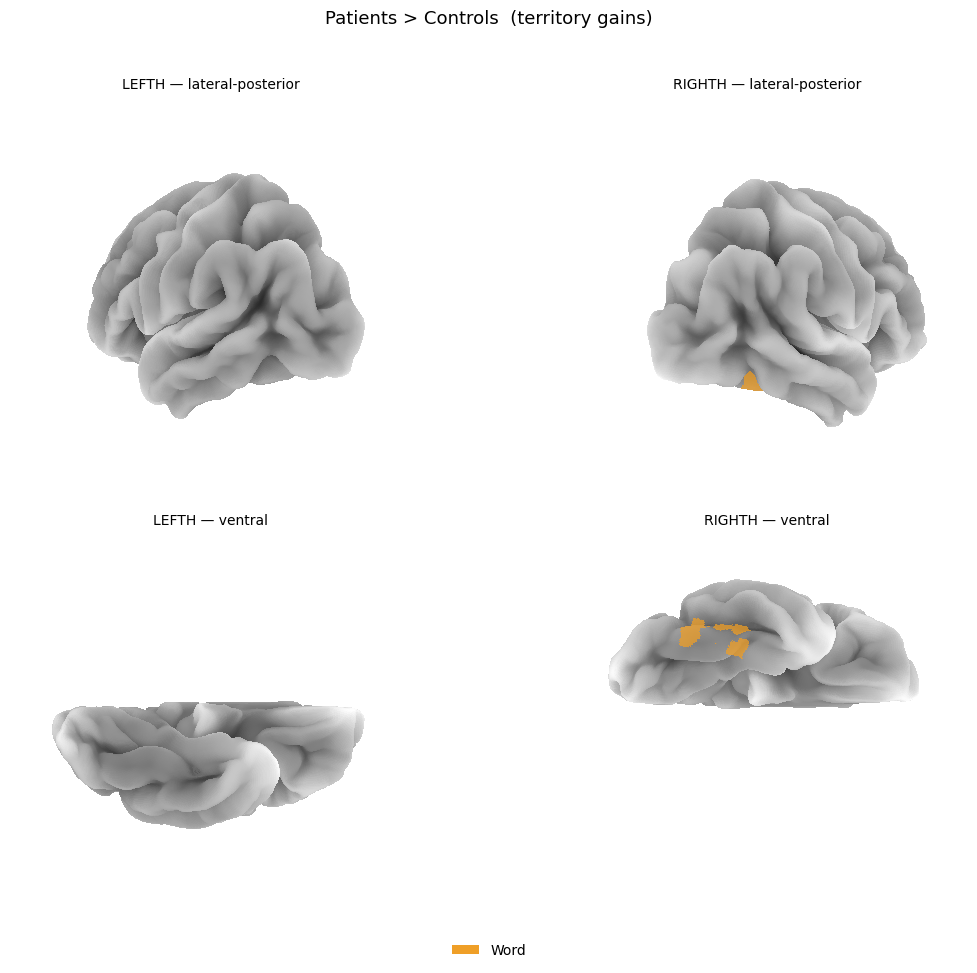


Controls > Patients  (territory losses)
  object_l tstat1: components [1073, 134, 12, 10] -> plotted 1207/1229 vox
  face_l tstat1: components [18, 12, 1] -> plotted 0/31 vox
  house_r tstat1: components [603, 34, 5, 1] -> plotted 603/643 vox


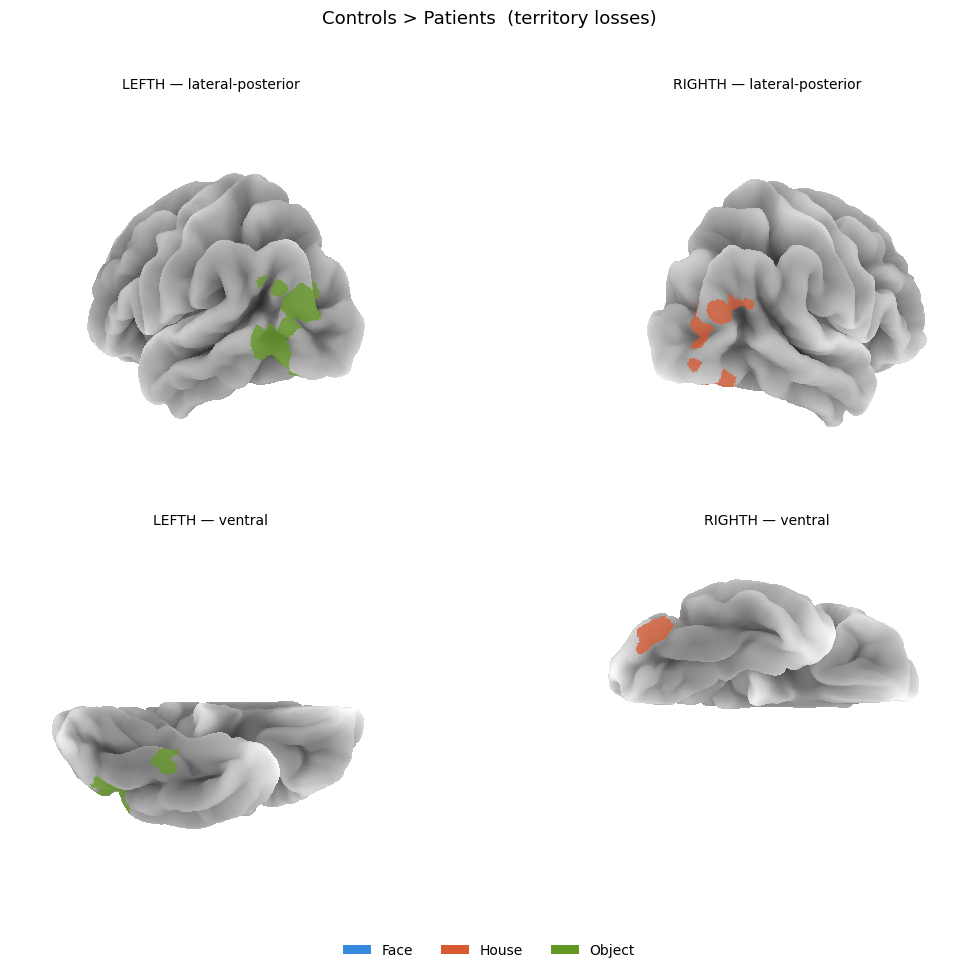

In [11]:
# ─── Fig 6: FDR-surviving TFCE clusters on inflated surfaces ─────────────
# Changes from the previous version:
#   MIN_COMPONENT_VOX  drops connected components below the floor, so minor
#                      patches (word_r's 72 and 58 vox) are not plotted
#   kind='ball' + 'nearest' + threshold 0.1 replaces line/linear/0.3, which
#                      perforated single components at sulcal vertices
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from nilearn import datasets as nl_datasets, surface
from nilearn.plotting import plot_surf_roi
from scipy import ndimage

MIN_COMPONENT_VOX = 100          # state this value in the caption
VERTEX_THRESH     = 0.1

CAT_COLORS = {'face': '#378ADD', 'house': '#D85A30',
              'object': '#639922', 'word': '#EF9F27'}
CAT_INT    = {'face': 1, 'house': 2, 'object': 3, 'word': 4}
TSTAT_FOR  = {'ctrl>pt': 1, 'pt>ctrl': 2}

GAINS_FDR  = [(r.category, r.hemi, TSTAT_FOR[r.direction])
              for r in REPORTABLE.itertuples() if r.direction == 'pt>ctrl']
LOSSES_FDR = [(r.category, r.hemi, TSTAT_FOR[r.direction])
              for r in REPORTABLE.itertuples() if r.direction == 'ctrl>pt']
print('GAINS_FDR :', GAINS_FDR)
print('LOSSES_FDR:', LOSSES_FDR)

VIEWS = {
    'l': [('lateral-posterior', 'lateral', (10, -150)),
          ('ventral',           'ventral', None)],
    'r': [('lateral-posterior', 'lateral', (10,  -30)),
          ('ventral',           'ventral', None)],
}

fsaverage = nl_datasets.fetch_surf_fsaverage(mesh='fsaverage')
cat_cmap  = ListedColormap(['#cccccc'] + [CAT_COLORS[c] for c in CATEGORIES])


def _keep_large_components(sig, min_vox):
    """Binary mask -> same mask with components under min_vox removed."""
    lab, n = ndimage.label(sig)
    if n == 0:
        return sig, []
    sizes = ndimage.sum(sig, lab, range(1, n + 1))
    keep = [i + 1 for i, s in enumerate(sizes) if s >= min_vox]
    return np.isin(lab, keep), sorted((int(s) for s in sizes), reverse=True)


def project_clusters_to_surface(cluster_list, hemi):
    hemi_full = 'left' if hemi == 'l' else 'right'
    n_vert = surface.load_surf_mesh(fsaverage[f'pial_{hemi_full}'])[0].shape[0]
    out = np.zeros(n_vert, dtype=np.int16)
    for cat, h, tstat in cluster_list:
        if h != hemi:
            continue
        fpath = TFCE_DIR / f'{cat}_{h}_pt_vs_ctrl' / CORRP_PATTERN.format(tstat=tstat)
        vol_img = nib.load(fpath)
        sig_raw = vol_img.get_fdata() > 0.95
        sig, sizes = _keep_large_components(sig_raw, MIN_COMPONENT_VOX)
        print(f'  {cat}_{h} tstat{tstat}: components {sizes} '
              f'-> plotted {int(sig.sum())}/{int(sig_raw.sum())} vox')
        sig_img = nib.Nifti1Image(sig.astype(np.float32), vol_img.affine)
        surf_vals = surface.vol_to_surf(
            sig_img, fsaverage[f'pial_{hemi_full}'],
            radius=3.0, kind='ball', interpolation='nearest',
        )
        out[surf_vals > VERTEX_THRESH] = CAT_INT[cat]
    return out


for label, cluster_list, tag in [
        ('Patients > Controls  (territory gains)', GAINS_FDR,  'gains'),
        ('Controls > Patients  (territory losses)', LOSSES_FDR, 'losses')]:
    if not cluster_list:
        print(f'no FDR-surviving clusters for: {label}')
        continue
    present = [c for c in CATEGORIES if c in {x[0] for x in cluster_list}]
    print(f'\n{label}')
    fig, axes = plt.subplots(2, 2, figsize=(12, 10), subplot_kw={'projection': '3d'})
    fig.suptitle(label, fontsize=13, y=0.98)

    for col, (hemi, hemi_full) in enumerate([('l', 'left'), ('r', 'right')]):
        roi_map = project_clusters_to_surface(cluster_list, hemi).astype(float)
        for row, (view_label, view_named, view_custom) in enumerate(VIEWS[hemi]):
            '''
            plot_surf_roi(
                fsaverage[f'infl_{hemi_full}'], roi_map=roi_map,
                hemi=hemi_full, view=view_named,
                cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
                bg_map=fsaverage[f'sulc_{hemi_full}'],
                bg_on_data=True, darkness=0.6,
                axes=axes[row, col], figure=fig,
            )
            '''
            plot_surf_roi(
                fsaverage[f'pial_{hemi_full}'], roi_map=roi_map,
                hemi=hemi_full, view=view_named,
                cmap=cat_cmap, vmin=0, vmax=4, threshold=0.5,
                bg_map=fsaverage[f'sulc_{hemi_full}'],
                bg_on_data=True, darkness=1.0, alpha=0.8,
                axes=axes[row, col], figure=fig,
            )
            if view_custom is not None:
                elev, azim = view_custom
                axes[row, col].view_init(elev=elev, azim=azim)
            axes[row, col].set_title(f'{hemi_full.upper()}H — {view_label}', fontsize=10)

    handles = [Patch(facecolor=CAT_COLORS[c], label=c.capitalize()) for c in present]
    fig.legend(handles=handles, loc='lower center', ncol=len(present),
               frameon=False, fontsize=10, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.04, 1, 0.96])
    plt.savefig(FIG_DIR / f'tfce_surface_fdr_{tag}.png', dpi=300, bbox_inches='tight')
    plt.show()